In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt


In [3]:
df=pd.read_csv('prices_round_0_day_-1.csv',delimiter=';')
df.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,TOMATOES,4999,5,4998,15,NaN,NaN,5013,5,5014,15,NaN,NaN,5006.0,0.0
1,-1,0,EMERALDS,9992,14,9990,29,NaN,NaN,10008,14,10010,29,NaN,NaN,10000.0,0.0
2,-1,100,EMERALDS,9992,11,9990,22,NaN,NaN,10008,11,10010,22,NaN,NaN,10000.0,0.0
3,-1,100,TOMATOES,5000,8,4998,21,NaN,NaN,5013,8,5014,21,NaN,NaN,5006.5,0.0
4,-1,200,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0


In [4]:
emeralds_data = df[df['product'] == 'EMERALDS']
tomato_data = df[df['product'] == 'TOMATOES']


In [14]:
print(emeralds_data['bid_price_1'][1:50])
print(emeralds_data['ask_price_1'][1:20])
print(emeralds_data['timestamp'][1:20])


2      9992
4      9992
7      9992
9      9992
10     9992
12     9992
15     9992
17     9992
18     9992
20     9992
23     9992
25     9992
26     9992
28     9992
31     9992
33     9992
34     9992
36     9992
39     9992
41     9992
42     9992
44     9992
47     9992
49     9992
50     9992
52     9992
55     9992
57     9992
58     9992
60     9992
63     9992
65     9992
66     9992
68     9992
71     9992
73     9992
74     9992
76     9992
79     9992
80     9992
83     9992
84    10000
87     9992
88     9992
91     9992
92     9992
95     9992
96     9992
99     9992
Name: bid_price_1, dtype: int64
2     10008
4     10008
7     10008
9     10008
10    10008
12    10008
15    10008
17    10008
18    10008
20    10008
23    10008
25    10008
26    10008
28    10008
31    10008
33    10008
34    10008
36    10008
39    10008
Name: ask_price_1, dtype: int64
2      100
4      200
7      300
9      400
10     500
12     600
15     700
17     800
18     900
20    1000
23    1100

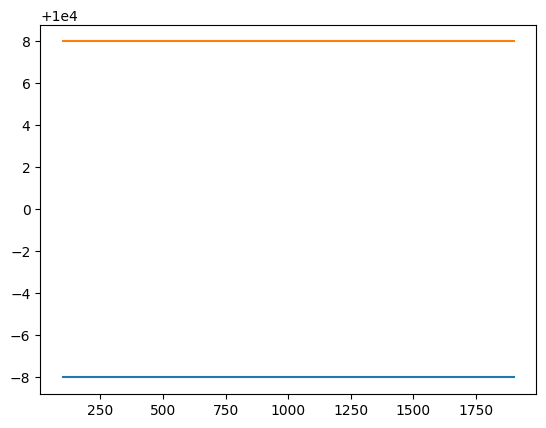

In [6]:
plt.plot(emeralds_data['timestamp'][1:20],emeralds_data['bid_price_1'][1:20])
plt.plot(emeralds_data['timestamp'][1:20],emeralds_data['ask_price_1'][1:20])
plt.show()

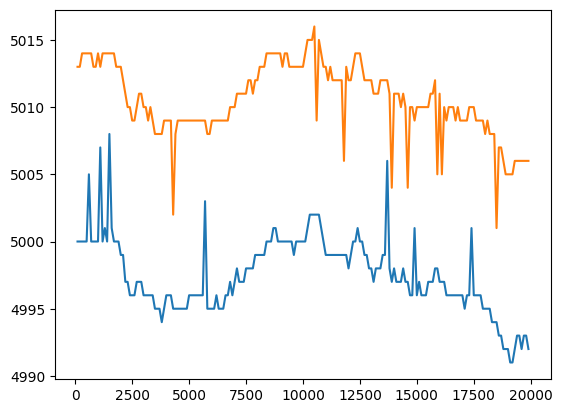

In [ ]:
plt.plot(tomato_data['timestamp'][1:200],tomato_data['bid_price_1'][1:200])
plt.plot(tomato_data['timestamp'][1:200],tomato_data['ask_price_1'][1:200])
plt.show()

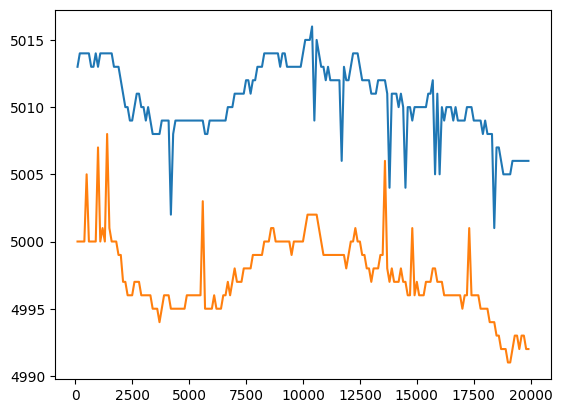

In [10]:
mini=[min(tomato_data['ask_price_1'].iloc[i],tomato_data['ask_price_2'].iloc[i], tomato_data['ask_price_3'].iloc[i]) for i in range(1,len(tomato_data))]
maxi=[max(tomato_data['bid_price_1'].iloc[i],tomato_data['bid_price_2'].iloc[i], tomato_data['bid_price_3'].iloc[i]) for i in range(1,len(tomato_data))]

plt.plot(tomato_data['timestamp'][1:200],mini[1:200])
plt.plot(tomato_data['timestamp'][1:200],maxi[1:200])
plt.show()

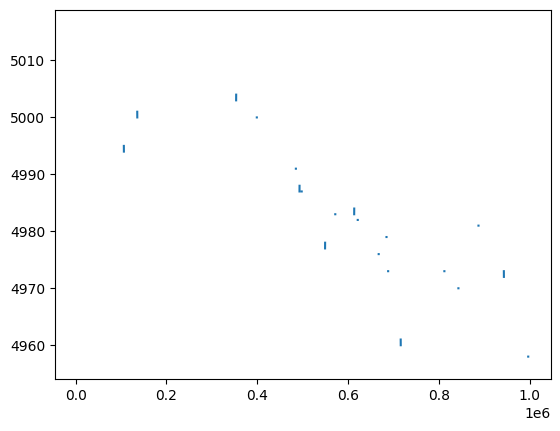

In [16]:
#plt.plot(tomato_data['timestamp'][1:200],tomato_data['ask_price_1'][1:200])
#plt.plot(tomato_data['timestamp'][1:200],tomato_data['ask_price_2'][1:200])
plt.plot(tomato_data['timestamp'],tomato_data['ask_price_3'])
plt.show()

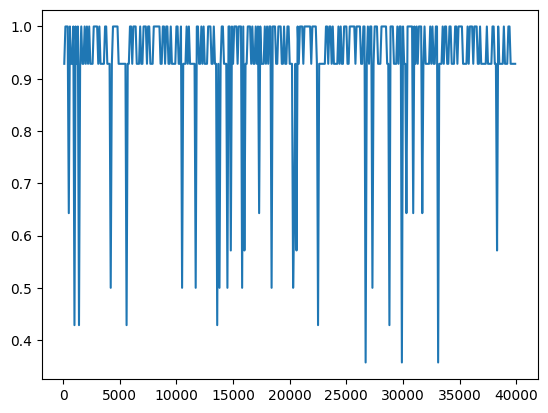

In [32]:
spread1=[tomato_data['ask_price_1'].iloc[i]-tomato_data['bid_price_1'].iloc[i] for i in range(1,len(tomato_data))]
plt.plot(tomato_data['timestamp'][1:400],spread1[1:400]/max(spread1[1:400]))


12.975197519751974


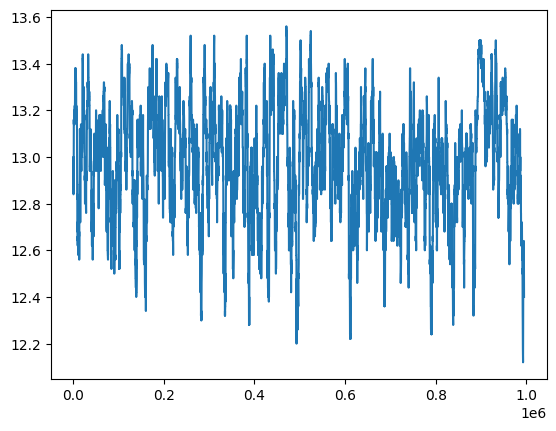

In [30]:
mean_spread1=sum(spread1)/len(spread1)
print(mean_spread1)

# rolling mean
rolling_mean_spread1=[sum(spread1[i:i+50])/50 for i in range(1,len(spread1)-50)]
plt.plot(tomato_data['timestamp'][1:len(rolling_mean_spread1)+1],rolling_mean_spread1)
plt.show()